<a href="https://colab.research.google.com/github/Jess-ssie/TravelJournal/blob/main/Lab_1__%D0%92%D1%80%D0%B5%D1%82%D1%96%D0%BA_%D0%84%D0%B2%D0%B3%D0%B5%D0%BD%D1%96%D1%8F_Working_in_the_Google_Colab_cloud_environment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 1

Дослідження джерел відкритих даних. Завантаження датасету та збереження даних в форматі csv. Робота в хмарному середовищі Google Colab.

*Виконала студентка групи КП-42*

*Вретік Євгенія*

*2026*

# Завдання 1: Аналіз великих даних

Використати відкритий набір даних Titanic dataset (інформація про пасажирів та їх
виживання).
Посилання на датасет:
https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv
Створити новий блокнот у середовищі Google Colab.
Перевірити доступні апаратні ресурси:
- визначити операційну систему;
- визначити кількість процесорів CPU.
Завантажити відкритий набір даних Titanic із мережі Інтернет.
Вивести перші 5 рядків таблиці для ознайомлення зі структурою даних.

Проаналізувати структуру даних:
- визначити типи даних;
- знайти пропущені значення.
Виконати агрегацію даних:
- визначити кількість пасажирів у кожному класі (pclass);
- визначити кількість тих, хто вижив у кожному класі.
Створити зведену таблицю (pivot table), що показує кількість тих, хто вижив залежно від класу
пасажира та статі.
Побудувати графік, що відображає кількість пасажирів у різних класах кают. Проаналізувати отримані
результати та зробити висновки.

Перевіримо доступні апаратні ресурси:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import platform
import multiprocessing

print("Операційна система:", platform.system())
print("Кількість CPU:", multiprocessing.cpu_count())

Операційна система: Linux
Кількість CPU: 2


Далі завантажимо відкритий набір даних Titanic із мережі Інтернет. Виведемо перші 5 рядків таблиці для ознайомлення зі структурою даних. Визначимо типи даних, знайдемо пропущені значення.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
data = pd.read_csv(url)

print("Перші 5 рядків датасету:")
display(data.head())

print("\nІнформація про структуру даних(які типи даних):")
data.info()

print("\nКількість пропущених значень у кожному стовпці:")
print(data.isnull().sum())

Перші 5 рядків датасету:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Інформація про структуру даних(які типи даних):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB

Кількість пропущених значень у кожному стовпці:
survived   

З цих результатів можна зробити висновки: у датасеті 891 запис, але в колонці deck (палуба) бракує аж 688 значень, а вік (age) невідомий для 177 пасажирів.

Тепер виконаємо агрегацію даних: визначимо кількість пасажирів у кожному класі (pclass); визначити кількість тих, хто вижив у кожному класі. Та створимо зведену таблицю (pivot table), що покаже кількість тих, хто вижив залежно від класу пасажира та статі:


In [ ]:
print("Кількість пасажирів у кожному класі:")
display(data['pclass'].value_counts().sort_index())

print("\nКількість пасажирів, хто вижив, у кожному класі:")
display(data[data['survived'] == 1]['pclass'].value_counts().sort_index())

pivot = data.pivot_table(
    values='survived',
    index='pclass',
    columns='sex',
    aggfunc='sum'
)

print("\nЗведена таблиця (кількість тих, хто вижив, за класом та статтю):")
display(pivot)

Кількість пасажирів у кожному класі:


,count
pclass,
1,216
2,184
3,491



Кількість пасажирів, хто вижив, у кожному класі:


,count
pclass,
1,136
2,87
3,119



Зведена таблиця (кількість тих, хто вижив, за класом та статтю):


sex,female,male
pclass,,
1,91,45
2,70,17
3,72,47


Побудуємо графік, що відображає кількість пасажирів у різних класах кают. Проаналізуємо отримані
результати:

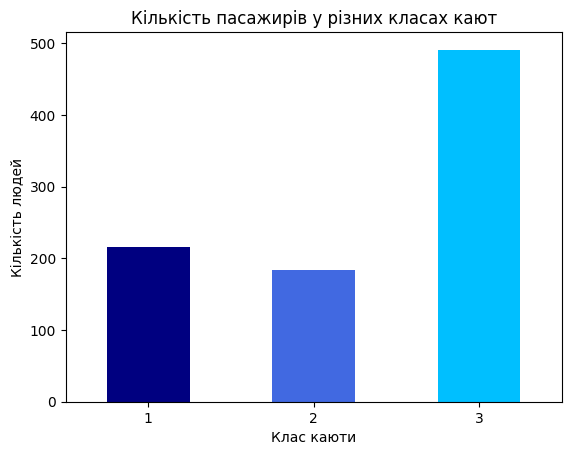

In [ ]:
data['pclass'].value_counts().sort_index().plot(kind='bar', color=['navy', 'royalblue', 'deepskyblue'])

plt.title("Кількість пасажирів у різних класах кают")
plt.xlabel("Клас каюти")
plt.ylabel("Кількість людей")
plt.xticks(rotation=0)
plt.show()

## Висновки до завдання

У ході виконання першого завдання було завантажено та проаналізовано датасет Titanic, що містить дані про 891 пасажира. Під час перевірки якості даних виявлено пропущені значення, найбільше з яких — у колонці deck (палуба).

Аналіз розподілу пасажирів показав, що переважна більшість людей (491) подорожувала у найдешевшому 3-му класі. У 1-му та 2-му класах перебувало 216 та 184 пасажири відповідно.

Агрегація даних щодо вцілілих показала, що найвищий абсолютний показник порятунку був серед пасажирів 1-го класу (136 осіб), попри те, що їх було значно менше, ніж у 3-му класі.

Побудована зведена таблиця показує, що в усіх класах жінки мали значно вищі шанси на виживання порівняно з чоловіками.

## Питання до завдання 1

**1. Що таке великі дані (Big Data) та які їх основні характеристики?**

Великі дані — це надзвичайно великі масиви структурованих та неструктурованих даних.

 Їхні основні характеристики (концепція 5V): Volume (величезний обсяг), Velocity (висока швидкість генерації), Variety (різноманітність форматів), Veracity (достовірність) та Value (корисна цінність).

**2. Що таке хмарні обчислення та які їх основні переваги для аналізу великих даних?**

Це надання обчислювальних ресурсів (серверів, сховищ, баз даних) через Інтернет.

Основні переваги: не потрібно купувати дороге власне обладнання, ресурси можна легко масштабувати залежно від потреб, а доступ до даних можливий з будь-якого місця.

**3. Які моделі надання хмарних послуг існують (SaaS, PaaS, IaaS)?**

IaaS (Інфраструктура як послуга): оренда "голих" серверів та мереж (наприклад, AWS, Google Compute Engine).

PaaS (Платформа як послуга): середовища для розробки та розгортання програм без налаштування ОС (наприклад, Google Colab).

SaaS (Програмне забезпечення як послуга): готові програми, доступні через браузер (наприклад, Google Drive, Gmail).

**4. Яке призначення середовища Google Colab та які його основні можливості?**

Це хмарне інтерактивне середовище для написання та виконання програмного коду мовою Python без необхідності встановлення самого Python чи бібліотек на локальний комп'ютер. Воно дозволяє працювати з даними у браузері, використовуючи обчислювальні ресурси віддалених віртуальних машин Google.  

**5. Які типи обчислювальних ресурсів доступні в Google Colab? У чому різниця?**

Доступні процесори CPU, GPU (графічні) та TPU (тензорні).  

 CPU підходить для стандартних послідовних задач (базова обробка даних).

 GPU використовується для паралельних обчислень (швидкого навчання нейромереж).

 TPU — спеціалізовані процесори від Google, оптимізовані виключно для роботи зі складними моделями машинного навчання.

**6. Що таке платформа Kaggle та для яких завдань вона використовується?**

Kaggle — це найбільша у світі онлайн-платформа для фахівців з Data Science. Вона використовується для пошуку безкоштовних відкритих датасетів, участі у змаганнях з машинного навчання та обміну готовими рішеннями (блокнотами) з іншими розробниками.

**7. Які бібліотеки мови Python найчастіше застосовуються для аналізу даних?**

Найпопулярніші: NumPy, pandas, Matplotlib, Seaborn, scikit-learn, XGBoost, SHAP.

**8. Яке призначення бібліотеки Pandas у процесі аналітики даних?**

Вона призначена для роботи з табличними структурами та наборами даних (їх завантаження, очищення, фільтрації, перетворення та аналізу).   

**9. Що таке DataFrame та які основні операції можна виконувати з цією структурою даних?**

DataFrame — це двовимірна таблична структура в Pandas (схожа на таблицю Excel з рядками та стовпцями). З нею можна виконувати: фільтрацію (пошук за умовою), групування, злиття кількох таблиць, видалення пропущених значень та математичні підрахунки.

**10. Які способи імпорту даних у DataFrame існують у бібліотеці Pandas?**

Читання файлів з комп'ютера або хмарних сховищ, таких як Google Drive. Також можна завантажувати дані напряму з мережі Інтернет за допомогою прямого посилання (URL).   

**11. Що таке відкриті дані та які основні формати їх зберігання?**

Це публічні дані, які кожен може вільно використовувати та поширювати.

Основні формати: CSV (значення, розділені комами), JSON (текстовий формат, схожий на словники Python) та XML (розширювана мова розмітки).

**12. Яке призначення функції read_csv() у бібліотеці Pandas?**

Вона зчитує дані з текстового файлу у форматі .csv і перетворює їх у табличну структуру DataFrame для подальшої роботи в Python.   

**13. Що таке агрегація даних та для чого вона використовується?**

Агрегація — це процес об'єднання розрізнених даних у загальні показники (сума, середнє значення, кількість). Це дозволяє побачити загальну картину замість тисяч окремих записів.

**14. Яке призначення методу pivot_table() та в яких задачах він застосовується?**

Він створює зведену таблицю, яка дозволяє перегрупувати дані за кількома ознаками одночасно (наприклад, як в лабораторній рахувала кількість тих, хто вижив, залежно від класу та статі).   

**15. Що таке описова статистика та які основні статистичні показники використовуються?**

Це методи короткого узагальнення характеристик даних (метод .describe() у Pandas).

Основні показники: кількість (count), середнє арифметичне (mean), мінімум, максимум, а також медіана.   

**16. Для чого використовуються засоби візуалізації даних?**

Для наочного представлення результатів аналізу, щоб людина могла миттєво побачити тренди, закономірності чи аномалії, які складно розгледіти у звичайній таблиці цифр.

**17. Які типи графіків використовуються для аналізу часових рядів?**

Лінійні графіки (Line chart) є найпопулярнішими для часових рядів, оскільки вони найкраще демонструють зміну значень (динаміку) з плином часу.
Також використовуються стовпчасті діаграми (Bar chart).

**18. Яке призначення бібліотеки Matplotlib у Python?**

Це основна бібліотека для побудови візуалізацій та графіків. Саме її я використовувала для малювання стовпчастих діаграм у завданні.

**19. Що таке часові ряди та які методи їх аналізу застосовуються у Big Data?**

Часовий ряд — це послідовність даних, записаних через рівні проміжки часу (наприклад, курс валют щодня).

Методи аналізу включають: виявлення довгострокового тренду, пошук сезонності, згладжування шумів (ковзне середнє) та прогнозування майбутніх значень.

**20. Які етапи включає типовий процес аналізу великих даних у хмарному середовищі?**

Відповідно до структури Notebook, це: завантаження датасету, первинний аналіз (огляд структури та пошук пропусків), попередня обробка даних, побудова аналітичних моделей, їх оцінювання та аналіз результатів (висновки).   

# Завдання 2: Вебскрепінг даних

Потрібно використати відкритий навчальний сайт для вебскрепінгу Books to Scrape, який
містить інформацію про книги (назва, ціна, рейтинг). Посилання: http://books.toscrape.com/

Потрібно:
1. Імпортувати необхідні бібліотеки Python.
2. Завантажити HTML-код головної сторінки сайту.
3. Виконати розбір HTML-документа.

4. Знайти елементи, що містять:
- назву книги;
- ціну книги.
5. Зібрати отримані дані у списки.
6. Створити таблицю даних у вигляді DataFrame за допомогою бібліотеки Pandas.
7. Вивести перші записи таблиці.
8. Зберегти отриманий набір даних у файл CSV.
9. Проаналізувати отримані результати та визначити:
- кількість знайдених книг;
- мінімальну та максимальну ціну.

In [ ]:
# 1. Імпорт необхідних бібліотек
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 2. Завантаження HTML-коду головної сторінки сайту
url = "http://books.toscrape.com/"
response = requests.get(url)

# 3. Розбір HTML-документа
soup = BeautifulSoup(response.text, "html.parser")

# 4. Знаходження елементів, що містять назву та ціну книги
# 5. Збір отриманих даних у списки
titles = []
prices = []

# Знаходження всіх блоків, де лежать книги
books = soup.find_all("article", class_="product_pod")

for book in books:
    title = book.find("h3").find("a")["title"]
    titles.append(title)

    price_text = book.find("p", class_="price_color").text

    clean_price = float(price_text.replace('Â', '').replace('£', ''))
    prices.append(clean_price)

# 6. Створення таблиці даних у вигляді DataFrame
data = pd.DataFrame({
    "Назва книги": titles,
    "Ціна(£)": prices
})

# 7. Виведення перших записів таблиці
print("Перші записи таблиці:")
display(data.head())

# 8. Збереження отриманого набору даних у файл CSV
data.to_csv("books.csv", index=False)
print("\nДані успішно збережені у файл 'books.csv'")

# 9. Проаналізувати отримані результати (кількість, мінімальна та максимальна ціна)
print("\nРезультати аналізу:")
print(f"Кількість знайдених книг на сторінці: {len(data)}")
print(f"Мінімальна ціна: £{data['Ціна(£)'].min()}")
print(f"Максимальна ціна: £{data['Ціна(£)'].max()}")

Перші записи таблиці:


,Назва книги,Ціна(£)
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23



Дані успішно збережені у файл 'books.csv'

Результати аналізу:
Кількість знайдених книг на сторінці: 20
Мінімальна ціна: £13.99
Максимальна ціна: £57.25


## Висновки до завдання

За допомогою бібліотек requests та BeautifulSoup було успішно виконано вебскрепінг сторінки Books to Scrape. Зібрано дані про 20 книг. Програмний аналіз створеного DataFrame показав, що найдешевша книга на сторінці коштує £13.99, а найдорожча — £57.25. Отриманий набір даних збережено у форматі CSV.

## Питання до завдання 2

**1. Що таке вебскрепінг та для чого він використовується в аналітиці даних?**

Вебскрепінг — це процес автоматизованого збору даних із вебсторінок в інтернеті. В аналітиці даних він використовується для витягування інформації з відкритих джерел, коли відсутні готові датасети чи API, що дозволяє формувати власні набори даних для подальшого дослідження.

**2. Які основні етапи процесу вебскрепінгу?**

Основними етапами є: імпорт необхідних бібліотек, завантаження HTML-сторінки, розбір (парсинг) HTML-документа, пошук необхідних елементів на сторінці та збереження отриманих даних у структурованому вигляді (наприклад, у DataFrame чи CSV-файл).

**3. Що таке HTML-документ і з яких основних елементів він складається?**

HTML-документ — це текстовий файл, написаний мовою гіпертекстової розмітки, який браузер інтерпретує у візуальну вебсторінку. Він складається з тегів (елементів), їхніх атрибутів та текстового вмісту, що формують ієрархічну структуру (шапки html, head, тіла body тощо).

**4. Що таке DOM-структура вебсторінки?**

DOM (Document Object Model) — це об'єктна модель документа, яка представляє вебсторінку у вигляді деревоподібної структури, де кожен вузол є об'єктом (елементом, тегом чи текстом), що дозволяє програмам звертатися до елементів сторінки та маніпулювати ними.

**5. Які основні HTML-теги використовуються для структурування вебсторінки?**

Для загальної структури використовуються html, head, body; для блоків і контейнерів — div, span; для заголовків — h1 – h6; для текстів і параграфів — p; для списків — ul, ol, li; для посилань — a; для таблиць — table, tr, td.

**6. Яке призначення бібліотеки Requests у Python?**

Бібліотека requests призначена для надсилання HTTP-запитів до вебсерверів та отримання відповідей (наприклад, завантаження HTML-коду сторінки) за допомогою простих і зручних команд.

**7. Які основні методи HTTP-запитів використовуються під час отримання вебданих?**

Основними є метод GET (використовується для отримання або завантаження вебсторінок і даних) та метод POST (використовується для надсилання даних на сервер, наприклад, при заповненні форм).

**8. Що таке HTTP-відповідь та які її основні компоненти?**

HTTP-відповідь — це повідомлення, яке сервер надсилає клієнту (браузеру чи скрипту) у відповідь на запит. Її основні компоненти: статус-код (наприклад, 200 OK, 404 Not Found), заголовки (headers) з метаданими та тіло відповіді (body), яке містить сам вміст (наприклад, HTML-код сторінки).

**9. Яке призначення бібліотеки Beautiful Soup?**

Бібліотека Beautiful Soup призначена для швидкого та зручного розбору (парсингу) HTML- та XML-документів, пошуку в них потрібних тегів, атрибутів і витягування текстової інформації.

**10. Які основні можливості бібліотеки Beautiful Soup для пошуку елементів HTML?**

Вона дозволяє здійснювати пошук за назвою тегу, за класом, за ідентифікатором (id), за допомогою атрибутів, а також за допомогою селекторів CSS або переміщенням по ієрархії дерева DOM (батьківські, дочірні та сусідні елементи).

**11. У чому різниця між методами find() та find_all() у Beautiful Soup?**

Метод find() повертає перший знайдений елемент, який відповідає критеріям пошуку (або None, якщо нічого не знайдено). Метод find_all() шукає по всьому документу й повертає список усіх знайдених елементів, що підходять під умови.

**12. Що таке атрибути HTML-тегів і як їх використовувати під час вебскрепінгу?**

Атрибути — це додаткові властивості тегів (наприклад, class, id, href, src, title), які задають параметри елементів. Під час вебскрепінгу вони використовуються для точної ідентифікації та фільтрації потрібних даних (наприклад, пошук тегів із конкретним класом, де лежить ціна чи назва).   

**13. Які основні формати збереження отриманих даних використовуються в аналітиці (CSV, JSON, Excel)?**

CSV: простий текстовий формат табличних даних, де значення розділені комами (найпопулярніший для простих датасетів).

JSON: текстовий формат на основі пар ключ-значення, ідеально підходить для вкладених та неструктурованих даних.

Excel (.xlsx): формат таблиць Microsoft Excel, зручний для роботи з формулами, стилями та звітами.

**14. Яке призначення бібліотеки Pandas під час обробки отриманих даних?**

Бібліотека pandas використовується для структурування зібраних зі сторінки даних у вигляді таблиць (DataFrame), їхнього очищення, фільтрації, сортування, проведення агрегації та подальшого статистичного аналізу.

**15. Що таке DataFrame та які його основні властивості?**

DataFrame — це двовимірна розмічена таблична структура даних у Pandas, що складається з рядків і стовпців (подібна до таблиці Excel).

 Його основні властивості: містить мітки рядків та назви стовпців, може зберігати дані різних типів у різних стовпцях, підтримує швидкі операції фільтрації, групування та математичні перетворення.

**16. Які етичні та правові аспекти потрібно враховувати під час вебскрепінгу?**

Необхідно поважати авторські права, не збирати персональні дані користувачів (ПДВ, приватну інформацію), не створювати надмірного навантаження на сервери частими запитами (робити паузи), а також перевіряти політику сайту щодо автоматизованого збору даних.  

**17. Що таке файл robots.txt і яку роль він відіграє при доступі до вебресурсів?**

Файл robots.txt — це текстовий файл у кореневому каталозі сайту, який повідомляє вебсканерам та роботам про те, які розділи чи сторінки сайту дозволено, а які заборонено відвідувати та сканувати.

**18. Які обмеження можуть виникати під час вебскрепінгу (CAPTCHA, блокування IP тощо)?**

Основними обмеженнями є блокування за IP-адресою при занадто частій відправці запитів, використання захисту від ботів (наприклад, CAPTCHA, Cloudflare), зміна структури HTML-коду сайту, а також обмеження швидкості завантаження сторінок з боку сервера.

**19. Які інструменти розробника браузера використовуються для пошуку HTML-елементів під час вебскрепінгу?**

Використовується вбудований «Інспектор» (Developer Tools, відкривається клавішею F12 або через контекстне меню «Дослідити елемент»), який дозволяє клікнути на будь-який елемент вебсторінки та миттєво побачити його HTML-код, структуру й класи в дереві DOM.

**20. У чому полягає роль вебскрепінгу у процесах аналізу великих даних?**

Вебскрепінг виступає первинним джерелом генерації та наповнення датасетів (Big Data) з відкритих інтернет-джерел у реальному часі, забезпечуючи надходження сирих даних, які після обробки та очищення використовуються для аналітики й побудови моделей.

# Завдання 3: Розподілені обчислення та обробка великих даних

Використати відкритий набір даних про автомобілі:
https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv

Набір містить інформацію про витрати палива автомобілів, потужність двигуна, масу автомобіля та інші
характеристики.

Потрібно:
1. Завантажити датасет у середовищі Google Colab.
2. Перетворити таблицю у Dask DataFrame.
3. Виконати аналіз даних:
- визначити середню витрату палива для різних країн виробництва;
- визначити максимальну потужність двигуна.
4. Побудувати графік залежності витрати палива від потужності двигуна.
5. Зробити короткі висновки щодо отриманих результатів.

Операційна система: Linux
Кількість доступних CPU: 2
Перші записи оригінального датасету:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



Середня витрата палива для різних країн виробництва:
origin
europe    27.891429
japan     30.450633
usa       20.083534
Name: mpg, dtype: float64

Максимальна потужність двигуна: 230.0


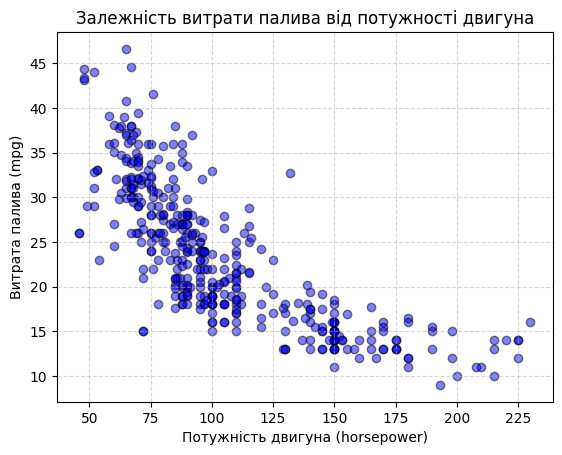

In [ ]:
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import platform
import multiprocessing

# 1. Перевірка доступних апаратних ресурсів
print("Операційна система:", platform.system())
print("Кількість доступних CPU:", multiprocessing.cpu_count())

# 2. Завантаження датасету про автомобілі (mpg) у середовищі Google Colab
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
pandas_df = pd.read_csv(url)

print("Перші записи оригінального датасету:")
display(pandas_df.head())

# 3. Перетворення таблиці у Dask DataFrame (для розподілених обчислень)
dask_df = dd.from_pandas(pandas_df, npartitions=2)

# Визначаємо середню витрату палива для різних країн виробництва
avg_mpg_by_origin = dask_df.groupby('origin')['mpg'].mean().compute()

print("\nСередня витрата палива для різних країн виробництва:")
print(avg_mpg_by_origin)

# Визначаємо максимальну потужність двигуна (horsepower)
max_horsepower = dask_df['horsepower'].max().compute()
print(f"\nМаксимальна потужність двигуна: {max_horsepower}")

# 4. Побудова графіка залежності витрати палива від потужності двигуна
plt.scatter(pandas_df['horsepower'], pandas_df['mpg'], color='blue', alpha=0.5, edgecolors='k')
plt.title("Залежність витрати палива від потужності двигуна")
plt.xlabel("Потужність двигуна (horsepower)")
plt.ylabel("Витрата палива (mpg)")
plt.grid(True, linestyl                 e='--', alpha=0.5)
plt.show()

## Висновки до завдання

За допомогою бібліотеки Dask було організовано розподілену обробку та аналіз відкритого датасету про автомобілі (mpg). Проведений аналіз показав, що максимальна потужність двигуна у вибірці становить 230 к.с. Розрахунок середньої витрати палива за регіонами продемонстрував, що найвищі показники економічності мають автомобілі з Японії та Європи. Побудована точкова діаграма наочно показує загальну тенденцію між потужністю двигуна та паливною ефективністю (mpg).

## Питання до завдання 3

1. **Що таке розподілені обчислення та які їх основні принципи?**

Це підхід до обробки даних, за якого складне завдання розбивається на менші частини, які виконуються одночасно на кількох незалежних комп'ютерах (вузлах), об'єднаних у мережу.

Основні принципи: паралелізм, децентралізація, масштабованість та відмовостійкість.

2. **Які основні переваги використання розподілених систем для обробки великих даних?**

Можливість обробляти масиви даних, які не поміщаються в пам'ять одного пристрою, значне прискорення обчислень за рахунок паралельної роботи, а також висока надійність і відмовостійкість.

3. **Які типи архітектур застосовуються у розподілених системах?**

Найпоширенішими є архітектура "клієнт-сервер", однорангова (Peer-to-Peer) архітектура, а також архітектура "майстер-воркер" (Master-Worker), де головний вузол керує завданнями, а робочі вузли їх виконують.

4. **Які основні характеристики великих даних (Big Data)?**

Основними характеристиками є концепція 5V: обсяг (Volume), швидкість (Velocity), різноманітність (Variety), достовірність (Veracity) та цінність (Value).

5. **Яку роль відіграє мова Python у системах аналізу великих даних?**

Python є провідною мовою завдяки багатій екосистемі спеціалізованих бібліотек для обробки даних, машинного навчання та розподілених обчислень, а також простоті синтаксису, що забезпечує швидку розробку.

6. **Які бібліотеки Python використовуються для розподілених обчислень великих даних?**

Основними бібліотеками є Dask, PySpark (через інтерфейс PySpark), Ray та Vaex.

7. **Яке призначення бібліотеки Dask?**

Dask призначена для паралельних та розподілених обчислень у Python. Вона дозволяє масштабувати звичні бібліотеки (Pandas, NumPy, Scikit-learn) на багатоядерні процесори або кластери для роботи з даними, що перевищують об'єм оперативної пам'яті.

8. **У чому відмінність між Pandas DataFrame і Dask DataFrame?**

Pandas DataFrame завантажує всі дані в пам'ять одного комп'ютера і виконує операції послідовно.

Dask DataFrame складається з багатьох невеликих таблиць Pandas (партицій), розподіляє обчислення на одразу і виконує їх ледачо (lazy evaluation) та паралельно.

9. **Що таке паралельні обчислення?**

Це процес виконання кількох обчислень чи операцій одночасно з метою прискорення вирішення загального завдання за рахунок поділу його на частини.

10. **Що таке багатопроцесорна обробка великих даних?**

Це підхід, за якого для виконання обчислень задіюються кілька фізичних або логічних ядер процесора (CPU) одночасно, що дозволяє обробляти великі масиви даних швидше завдяки паралельним потокам.

11. **Які ресурси доступні у середовищі Google Colab?**

У хмарному середовищі Google Colab доступні обчислювальні ресурси на базі центральних процесорів (CPU), графічних прискорювачів (GPU) та тензорних процесорів (TPU), а також операторам надається оперативна пам'ять і дисковий простір.

12. **У чому різниця між CPU, GPU та TPU?**

- **CPU** — універсальний процесор для послідовних і логічних завдань.
- **GPU** — графічний процесор, оптимізований для масивних паралельних обчислень (швидкого навчання нейромереж).
- **TPU** — спеціалізований чіп від Google, розроблений виключно для прискорення робочих навантажень глибокого навчання (TensorFlow).


13. **Що таке агрегація даних у процесі аналітики?**

Це згортання, узагальнення та комбінування набору даних для отримання підсумкових метрик (сума, середнє значення, кількість тощо) за певними критеріями.

14. **Що таке групування даних (groupby)?**

Це операція розділення даних на групи за певними ознаками (наприклад, за категоріями чи країнами) для подальшого застосування до кожної групи окремих статистичних функцій.

15. **Які методи використовуються для аналізу великих наборів даних?**

Фільтрація, агрегація, групування, злиття (join/merge), машинне навчання, статистичний аналіз, а також розподілені обчислення за допомогою кластерів.

16. **Що таке розподілене зберігання даних?**

Це спосіб зберігання інформації, коли великий набір даних розбивається на частини та зберігається на базі багатьох незалежних фізичних серверів або вузлів у мережі.

17. **Які переваги хмарних обчислень для аналізу великих даних?**

Відсутність потреби купувати власне дороге "залізо", гнучке масштабування ресурсів (додавання потужностей за потреби) та доступність інструментів аналізу з будь-якого місця через інтернет.

18. **Що таке масштабованість системи обробки даних?**

Здатність системи ефективно справлятися зі збільшенням обсягів даних чи навантаження шляхом додавання нових ресурсів (обчислювальних потужностей або пам'яті).

19. **Які проблеми можуть виникати під час розподілених обчислень?**

Мережеві затримки (overhead на передачу даних між вузлами), складність налагодження коду, забезпечення консистентності даних та ризики відмови окремих вузлів системи.

20. **Яку роль відіграють розподілені обчислення у сучасних інформаційних системах?**

Вони є основою для функціонування систем обробки Big Data, хмарних платформ, пошукових систем, соціальних мереж та штучного інтелекту, дозволяючи аналізувати петабайти інформації в реальному часі.

# Висновки

У ході виконання лабораторної роботи № 1 я дослідила джерела відкритих даних та отримала практичні навички їх завантаження, обробки, аналізу та збереження.

Виконуючи перше завдання, я проаналізувала датасет Titanic за допомогою бібліотеки Pandas, визначила розподіл пасажирів за класами та кількість тих, хто вижив, а також створила зведену таблицю та графік.

У другому завданні я виконала вебскрепінг сайту Books to Scrape за допомогою бібліотек Requests і BeautifulSoup, після чого отримані дані було представлено у вигляді DataFrame та збережено у форматі CSV.

У третьому завданні я використала бібліотеку Dask для обробки датасету автомобілів та виконала групування даних, розрахунок середніх значень і пошук максимальної потужності двигуна. Також побудовала графік залежності витрати палива від потужності двигуна.

 У результаті роботи я отримала практичний досвід роботи з відкритими даними, бібліотеками Pandas, BeautifulSoup, Dask та засобами візуалізації Python у середовищі Google Colab.